# Training Model Kategori dan Prioritas (Klasifikasi Kategori dan Prioritas Dokumen)

Notebook ini bertujuan untuk melakukan *fine-tuning* pada model NLP (Natural Language Processing) berbasis *Transformer* menggunakan arsitektur **IndoBERT** (`indobenchmark/indobert-base-p1`) dengan *framework* **PyTorch**. Model ini dikembangkan untuk mengklasifikasikan kategori dokumen internal perusahaan (Tiket IT, Email HR, Laporan Keuangan, SOP, dan Permintaan Pengadaan) sekaligus memprediksi tingkat prioritasnya (Tinggi, Sedang, Rendah). Model klasifikasi ini akan menjadi mesin utama (*core engine*) dalam mendukung otomatisasi dokumen pada aplikasi **SnapFlow (AI Workplace Assistant)**.

## Proses Pengerjaan:

1. **Preprocessing & Tokenisasi:** Mengonversi label teks (kategori & prioritas) menjadi representasi numerik menggunakan *Label Encoding*, serta memproses teks mentah menggunakan *BertTokenizer* bawaan IndoBERT dengan penyesuaian parameter `max_length`.
2. **Fine-Tuning Model IndoBERT:** Mengonfigurasi arsitektur *pre-trained* model `indobenchmark/indobert-base-p1` menggunakan library Hugging Face Transformers untuk tugas klasifikasi teks multi-kelas.
3. **Training & Evaluasi Performa:** Melatih model menggunakan PyTorch dengan pembagian data berbasis *Stratified Split* (80% Train, 10% Validation, 10% Test) serta mengukur performanya menggunakan metrik *Accuracy* dan *F1-Score* untuk mengejar target akurasi di atas 85%.
4. **Menyimpan & Ekspor Model:** Menyimpan *state* dan bobot (*weights*) model yang telah optimal agar siap diekspor dan diintegrasikan sebagai *endpoint REST API* berbasis FastAPI.

## **Import Library**

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn torch transformers dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import dagshub
import mlflow
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

In [3]:
dagshub.init(repo_owner='lintinggg', repo_name='SnapFlow-Model', mlflow=True)

# Set tracking URI biar MLflow tahu harus ngirim data ke mana
mlflow.set_tracking_uri("https://dagshub.com/lintinggg/SnapFlow-Model.mlflow")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=8d2fdbb8-dd1c-4614-9254-a942aec95a80&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=09b09b84843ae9b458b25653ea70bdaeb7c5e7bfbc5dea7a0895f3a207b03510




Accessing as lintinggg

Initialized MLflow to track repo "lintinggg/SnapFlow-Model"

Repository lintinggg/SnapFlow-Model initialized!

## **Preprocessing**

Load Dataset

In [4]:
df = pd.read_csv('dataset_clean.csv')

df.head()

,teks,kategori,prioritas
0,"Email dari Budi Santoso, Divisi Keuangan. Berd...",Laporan Keuangan,Tinggi
1,"Laporan dari Siti Rahmawati, Divisi Akuntansi....",Laporan Keuangan,Tinggi
2,"Email dari Andi Prasetyo, Divisi Treasury. Pos...",Laporan Keuangan,Tinggi
3,"Laporan dari Rina Kusuma, Divisi Audit Interna...",Laporan Keuangan,Tinggi
4,"Email dari Dedi Saputra, Divisi Pengadaan. Dit...",Laporan Keuangan,Tinggi


Label Encoding

In [5]:
le_kategori = LabelEncoder()
le_prioritas = LabelEncoder()

df['kategori_encode'] = le_kategori.fit_transform(df['kategori'])
df['prioritas_encode'] = le_prioritas.fit_transform(df['prioritas'])

df.head()

,teks,kategori,prioritas,kategori_encode,prioritas_encode
0,"Email dari Budi Santoso, Divisi Keuangan. Berd...",Laporan Keuangan,Tinggi,1,2
1,"Laporan dari Siti Rahmawati, Divisi Akuntansi....",Laporan Keuangan,Tinggi,1,2
2,"Email dari Andi Prasetyo, Divisi Treasury. Pos...",Laporan Keuangan,Tinggi,1,2
3,"Laporan dari Rina Kusuma, Divisi Audit Interna...",Laporan Keuangan,Tinggi,1,2
4,"Email dari Dedi Saputra, Divisi Pengadaan. Dit...",Laporan Keuangan,Tinggi,1,2


In [6]:
for a, b in enumerate(le_kategori.classes_):
  print(a, b)

0 Email HR
1 Laporan Keuangan
2 Permintaan Pengadaan
3 SOP
4 Tiket IT


In [7]:
for a, b in enumerate(le_prioritas.classes_):
  print(a, b)

0 Rendah
1 Sedang
2 Tinggi


Split Data

In [8]:
X = df['teks']

# Split Kategori
y_cat = df['kategori_encode']
y_prio = df['prioritas_encode']

# Bagi Train Kategori
X_train_cat, X_temp_cat, y_train_cat, y_temp_cat = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)
# Bagi Val sama Test Kategori
X_val_cat, X_test_cat, y_val_cat, y_test_cat = train_test_split(
    X_temp_cat, y_temp_cat, test_size=0.5, random_state=42, stratify=y_temp_cat
)

# Bagi Train Prioritas
X_train_prio, X_temp_prio, y_train_prio, y_temp_prio = train_test_split(
    X, y_prio, test_size=0.2, random_state=42, stratify=y_prio
)

# Bagi Validasi sama Test Prioritas
X_val_prio, X_test_prio, y_val_prio, y_test_prio = train_test_split(
    X_temp_prio, y_temp_prio, test_size=0.5, random_state=42, stratify=y_temp_prio
)

Tokenisasi

In [9]:
tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Tokenisasi hasil split Kategori
train_encodings_cat = tokenize_data(X_train_cat)
val_encodings_cat = tokenize_data(X_val_cat)
test_encodings_cat = tokenize_data(X_test_cat)

# Tokenisasi hasil split Prioritas
train_encodings_prio = tokenize_data(X_train_prio)
val_encodings_prio = tokenize_data(X_val_prio)
test_encodings_prio = tokenize_data(X_test_prio)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## **Fine Tuning**

In [10]:
class SnapFlowDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Narik token per baris data
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Masukin label targetnya
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset_cat = SnapFlowDataset(train_encodings_cat, y_train_cat.tolist())
val_dataset_cat = SnapFlowDataset(val_encodings_cat, y_val_cat.tolist())
test_dataset_cat = SnapFlowDataset(test_encodings_cat, y_test_cat.tolist())

train_dataset_prio = SnapFlowDataset(train_encodings_prio, y_train_prio.tolist())
val_dataset_prio = SnapFlowDataset(val_encodings_prio, y_val_prio.tolist())
test_dataset_prio = SnapFlowDataset(test_encodings_prio, y_test_prio.tolist())

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Target Capstone lu >85% [cite: 98]
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1_macro': f1
    }

Training Model Kategori

In [12]:
eksperimen_list = [
    {"nama": "Skenario_A_LR3e-5", "lr": 3e-5, "batch": 16, "epoch": 3},
    {"nama": "Skenario_B_LR5e-5", "lr": 5e-5, "batch": 16, "epoch": 3},
]

print("Mulai proses eksperimen Fine-Tuning Kategori...\n")

for eksperimen in eksperimen_list:
    print(f"=== Menjalankan: {eksperimen['nama']} ===")

    local_dir = f"./results_cat_{eksperimen['nama']}"

    model_cat = BertForSequenceClassification.from_pretrained(
        'indobenchmark/indobert-base-p1',
        num_labels=5
    )

    with mlflow.start_run(run_name=eksperimen['nama']):

        training_args_dinamis = TrainingArguments(
            output_dir=local_dir,
            num_train_epochs=eksperimen['epoch'],
            per_device_train_batch_size=eksperimen['batch'],
            per_device_eval_batch_size=eksperimen['batch'],
            learning_rate=eksperimen['lr'],
            warmup_steps=100,
            weight_decay=0.01,
            logging_steps=10,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model='accuracy',
            report_to="mlflow"
        )

        trainer = Trainer(
            model=model_cat,
            args=training_args_dinamis,
            train_dataset=train_dataset_cat,
            eval_dataset=val_dataset_cat,
            compute_metrics=compute_metrics,
        )

        trainer.train()

        print(f"Evaluasi Data Test untuk {eksperimen['nama']}...")
        test_results = trainer.evaluate(test_dataset_cat)

        mlflow.log_metrics({
            "test_accuracy": test_results["eval_accuracy"],
            "test_f1": test_results["eval_f1_macro"]
        })

        mlflow.log_artifacts(local_dir, artifact_path="model_files")

        print(f"=== {eksperimen['nama']} Selesai! ===\n")

Mulai proses eksperimen Fine-Tuning Kategori...

=== Menjalankan: Skenario_A_LR3e-5 ===


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluasi Data Test untuk Skenario_B_LR5e-5...


/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.001682,0.047005,3,1.000000,1.000000


=== Skenario_B_LR5e-5 Selesai! ===

🏃 View run Skenario_B_LR5e-5 at: https://dagshub.com/lintinggg/SnapFlow-Model.mlflow/#/experiments/0/runs/e0838a9a2b114661aa926ba0e5813c4e
🧪 View experiment at: https://dagshub.com/lintinggg/SnapFlow-Model.mlflow/#/experiments/0


Evaluasi Model

In [13]:
test_predictions = trainer.predict(test_dataset_cat)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [14]:
target_names = le_kategori.classes_

In [15]:
print("=== CLASSIFICATION REPORT: KATEGORI DOKUMEN ===\n")
print(classification_report(y_true, y_pred, target_names=target_names))

=== CLASSIFICATION REPORT: KATEGORI DOKUMEN ===

                      precision    recall  f1-score   support

            Email HR       1.00      1.00      1.00        19
    Laporan Keuangan       1.00      1.00      1.00        21
Permintaan Pengadaan       1.00      1.00      1.00        21
                 SOP       1.00      1.00      1.00        22
            Tiket IT       1.00      1.00      1.00        18

            accuracy                           1.00       101
           macro avg       1.00      1.00      1.00       101
        weighted avg       1.00      1.00      1.00       101



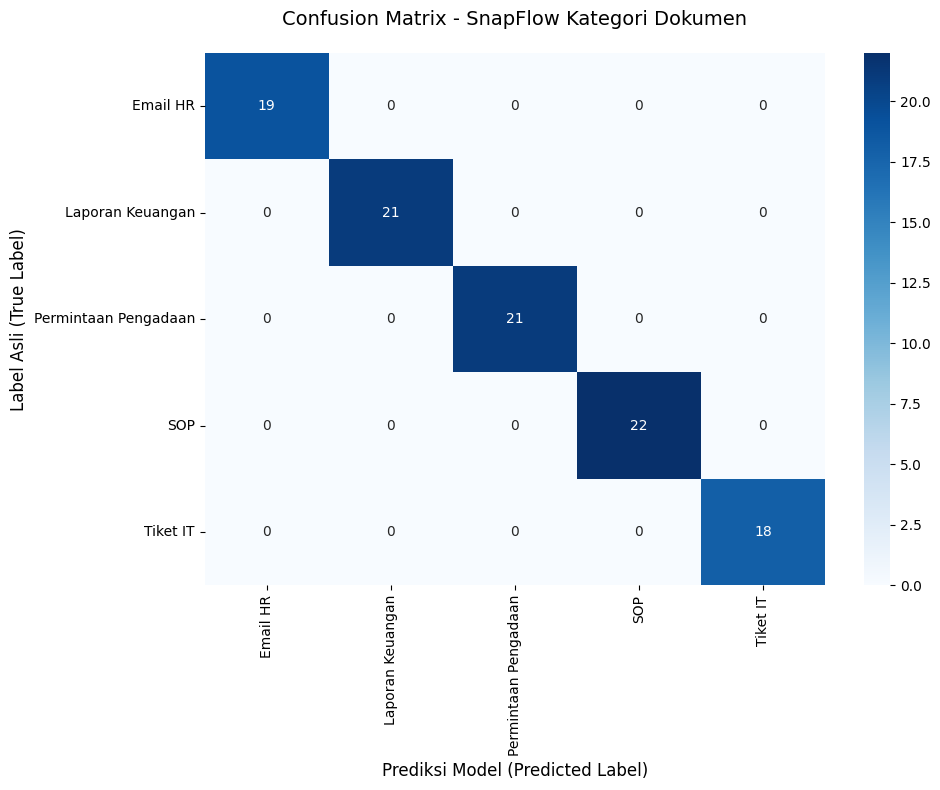

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - SnapFlow Kategori Dokumen', pad=20, fontsize=14)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.tight_layout()
plt.show()

Training Model Prioritas

In [17]:
eksperimen_prio_list = [
    {"nama": "Prioritas_Skenario_Aman_LR3e-5", "lr": 3e-5, "batch": 16, "epoch": 3},
    {"nama": "Prioritas_Skenario_Cepat_LR5e-5", "lr": 5e-5, "batch": 16, "epoch": 3},
]

print("=== Mulai Fine-Tuning Tingkat Prioritas ===\n")

for eksperimen in eksperimen_prio_list:
    print(f">> Menjalankan Skenario: {eksperimen['nama']} <<")

    local_dir = f"./results_prio_{eksperimen['nama']}"

    model_prio = BertForSequenceClassification.from_pretrained(
        'indobenchmark/indobert-base-p1',
        num_labels=3
    )

    with mlflow.start_run(run_name=eksperimen['nama']):

        training_args_prio = TrainingArguments(
            output_dir=f"./results_prio_{eksperimen['nama']}",
            num_train_epochs=eksperimen['epoch'],
            per_device_train_batch_size=eksperimen['batch'],
            per_device_eval_batch_size=eksperimen['batch'],
            learning_rate=eksperimen['lr'],
            warmup_steps=100,
            weight_decay=0.01,
            logging_steps=10,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model='accuracy',
            report_to="mlflow"
        )

        trainer_prio = Trainer(
            model=model_prio,
            args=training_args_prio,
            train_dataset=train_dataset_prio,
            eval_dataset=val_dataset_prio,
            compute_metrics=compute_metrics,
        )

        trainer_prio.train()

        test_results = trainer_prio.evaluate(test_dataset_prio)
        mlflow.log_metrics({
            "test_accuracy": test_results["eval_accuracy"],
            "test_f1": test_results["eval_f1_macro"]
        })

        mlflow.log_artifacts(local_dir, artifact_path="model_files")

        print(f"Skenario {eksperimen['nama']} Selesai!\n")

=== Mulai Fine-Tuning Tingkat Prioritas ===

>> Menjalankan Skenario: Prioritas_Skenario_Aman_LR3e-5 <<


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.839606,0.671552,0.800000,0.790989
2,0.510020,0.384612,0.850000,0.849128
3,0.077582,0.333170,0.890000,0.890353


...

/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.039464,0.306956,3,0.930693,0.930910


Skenario Prioritas_Skenario_Cepat_LR5e-5 Selesai!

🏃 View run Prioritas_Skenario_Cepat_LR5e-5 at: https://dagshub.com/lintinggg/SnapFlow-Model.mlflow/#/experiments/0/runs/ab7c2a7a935a4ccbafe37ee1948439a4
🧪 View experiment at: https://dagshub.com/lintinggg/SnapFlow-Model.mlflow/#/experiments/0


Evaluasi Model

In [18]:
test_predictions_prio = trainer_prio.predict(test_dataset_prio)
y_pred_prio = np.argmax(test_predictions_prio.predictions, axis=-1)
y_true_prio = test_predictions_prio.label_ids

/tmp/ipykernel_1969/3290503408.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [19]:
target_names_prio = le_prioritas.classes_

In [20]:
print("=== CLASSIFICATION REPORT: PRIORITAS DOKUMEN ===\n")
print(classification_report(y_true_prio, y_pred_prio, target_names=target_names_prio))

=== CLASSIFICATION REPORT: PRIORITAS DOKUMEN ===

              precision    recall  f1-score   support

      Rendah       0.93      0.90      0.92        31
      Sedang       0.92      0.89      0.90        37
      Tinggi       0.94      1.00      0.97        33

    accuracy                           0.93       101
   macro avg       0.93      0.93      0.93       101
weighted avg       0.93      0.93      0.93       101



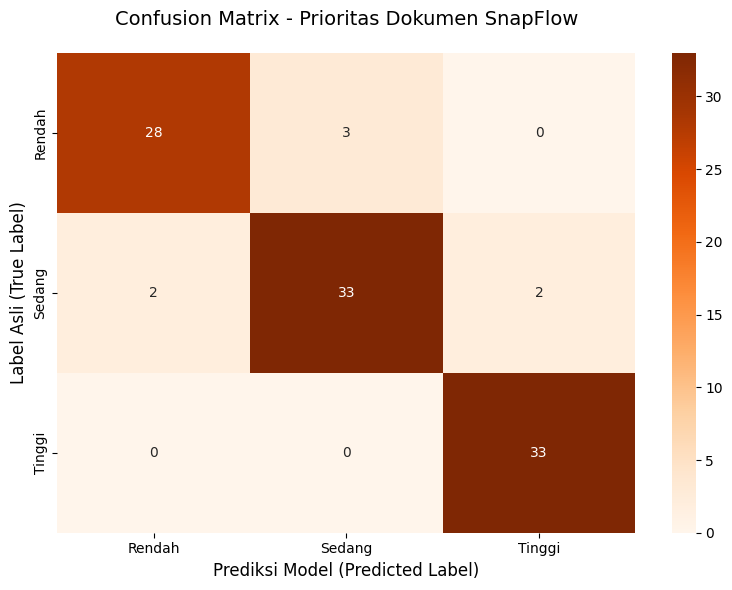

In [21]:
cm_prio = confusion_matrix(y_true_prio, y_pred_prio)
plt.figure(figsize=(8, 6))

sns.heatmap(cm_prio, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names_prio, yticklabels=target_names_prio)
plt.title('Confusion Matrix - Prioritas Dokumen SnapFlow', pad=20, fontsize=14)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
plt.ylabel('Label Asli (True Label)', fontsize=12)

plt.tight_layout()
plt.show()

## Eksport Model

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import os

os.makedirs('/content/drive/MyDrive/SnapFlow_Models/indobert_kategori', exist_ok=True)
os.makedirs('/content/drive/MyDrive/SnapFlow_Models/indobert_prioritas', exist_ok=True)

print("Menyimpan Model IndoBERT Kategori...")
trainer.save_model('/content/drive/MyDrive/SnapFlow_Models/indobert_kategori')
tokenizer.save_pretrained('/content/drive/MyDrive/SnapFlow_Models/indobert_kategori')

print("Menyimpan Model IndoBERT Prioritas...")
trainer_prio.save_model('/content/drive/MyDrive/SnapFlow_Models/indobert_prioritas')
tokenizer.save_pretrained('/content/drive/MyDrive/SnapFlow_Models/indobert_prioritas')

print("Semua model IndoBERT berhasil diekspor ke Google Drive lu!")

Menyimpan Model IndoBERT Kategori...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Menyimpan Model IndoBERT Prioritas...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Semua model IndoBERT berhasil diekspor ke Google Drive lu!


In [24]:
import joblib

print("Mengunduh & melatih ulang Baseline SVM pada seluruh dataset...")

# Latih ulang SVM Kategori dengan seluruh data
pipeline_svm_full_cat = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    SVC(kernel='linear', C=1.0, random_state=42)
)
pipeline_svm_full_cat.fit(df['teks'], df['kategori_encode'])

# Save ke Google Drive
joblib.dump(pipeline_svm_full_cat, '/content/drive/MyDrive/SnapFlow_Models/svm_kategori_baseline.pkl')
print("Model Baseline SVM berhasil diekspor ke Google Drive!")

Mengunduh & melatih ulang Baseline SVM pada seluruh dataset...
Model Baseline SVM berhasil diekspor ke Google Drive!


Model SVM + N-Gram Kategori dan Prioritas

In [25]:
X_cv = df['teks']
y_cv = df['kategori_encode']

X_cv = df['teks']
y_prio_cv = df['prioritas_encode']

In [26]:
pipeline_svm = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    SVC(kernel='linear', C=1.0, random_state=42)
)

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Memulai 5-Fold Cross Validation dengan SVM + TF-IDF")

Memulai 5-Fold Cross Validation dengan SVM + TF-IDF


In [28]:
cv_scores = cross_val_score(pipeline_svm, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)

In [29]:
print("=== HASIL SANITY CHECK DATA LEAKAGE ===")
for i, score in enumerate(cv_scores, 1):
    print(f"Lipatan (Fold) {i}: Akurasi = {score * 100:.2f}%")

print("-" * 35)
print(f"Rata-rata Akurasi : {np.mean(cv_scores) * 100:.2f}%")
print(f"Standar Deviasi   : {np.std(cv_scores) * 100:.2f}%")

=== HASIL SANITY CHECK DATA LEAKAGE ===
Lipatan (Fold) 1: Akurasi = 100.00%
Lipatan (Fold) 2: Akurasi = 100.00%
Lipatan (Fold) 3: Akurasi = 100.00%
Lipatan (Fold) 4: Akurasi = 100.00%
Lipatan (Fold) 5: Akurasi = 100.00%
-----------------------------------
Rata-rata Akurasi : 100.00%
Standar Deviasi   : 0.00%


In [30]:
pipeline_svm_prio = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    SVC(kernel='linear', C=1.0, random_state=42)
)

In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Memulai 5-Fold Cross Validation untuk TINGKAT PRIORITAS...\n")

Memulai 5-Fold Cross Validation untuk TINGKAT PRIORITAS...



In [32]:
cv_scores_prio = cross_val_score(pipeline_svm_prio, X_cv, y_prio_cv, cv=skf, scoring='accuracy', n_jobs=-1)

In [33]:
print("=== HASIL SANITY CHECK: MODEL PRIORITAS ===")
for i, score in enumerate(cv_scores_prio, 1):
    print(f"Lipatan (Fold) {i}: Akurasi = {score * 100:.2f}%")

print("-" * 35)
rata_akurasi_prio = np.mean(cv_scores_prio) * 100
print(f"Rata-rata Akurasi : {rata_akurasi_prio:.2f}%")
print(f"Standar Deviasi   : {np.std(cv_scores_prio) * 100:.2f}%")

=== HASIL SANITY CHECK: MODEL PRIORITAS ===
Lipatan (Fold) 1: Akurasi = 92.04%
Lipatan (Fold) 2: Akurasi = 89.55%
Lipatan (Fold) 3: Akurasi = 87.56%
Lipatan (Fold) 4: Akurasi = 90.55%
Lipatan (Fold) 5: Akurasi = 92.04%
-----------------------------------
Rata-rata Akurasi : 90.35%
Standar Deviasi   : 1.68%
